# Import Libraries


In [1201]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from IPython import display

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [1202]:
# params_cfg = {
#     "action"  : "main_feat01",  
#     "seed"    : 42, # Set random seed
#     "exp_dir" : os.path.abspath('../../exps'),
#     'exp_name': 'featbase_06112025',
#     "data_dir": os.path.abspath("../../data/titanic"),
#     "verbose" : True,
# }
params_cfg = {
    "action"   : "train_feat01",  
    "feat_path": "../../exps/featbase_06112025/data.npz",
    "seed"    : 42, # Set random seed
    "exp_dir" : os.path.abspath('../../exps'),
    'exp_name': 'train_06112025',
    "data_dir": os.path.abspath("../../../data"),
    "verbose" : True,
}
params_cfg.update(**{
    "save_dir": os.path.abspath(f'{params_cfg["exp_dir"]}/{params_cfg["exp_name"]}')
})

for v in params_cfg:
    print(f'+ {v}: {params_cfg[v]}')

globals().update(**params_cfg)

+ action: train_feat01
+ feat_path: ../../exps/featbase_06112025/data.npz
+ seed: 42
+ exp_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\process\exps
+ exp_name: train_06112025
+ data_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\data
+ verbose: True
+ save_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\process\exps\train_06112025


# Data Load


In [1203]:
df_train = pd.read_csv(f'{data_dir}/train.csv')
df_test = pd.read_csv(f'{data_dir}/test.csv')

if params_cfg["verbose"]:
    print("-"*10, "information", "-"*10)
    print(f'train-col: {set(df_train.columns)}')
    print(f'test-col: {set(df_test.columns)}')
    print("Union:", set(df_train.columns).intersection(set(df_test.columns)))
    print("Difference:", set(df_train.columns).difference(set(df_test.columns)))

---------- information ----------
train-col: {'GarageType', 'Exterior1st', 'MiscVal', 'MoSold', 'Alley', 'GarageYrBlt', 'BldgType', 'GrLivArea', 'MSZoning', 'BsmtQual', 'Fireplaces', 'HalfBath', 'RoofStyle', 'GarageCars', 'LotFrontage', 'OverallCond', 'BsmtCond', 'BsmtFinType2', 'EnclosedPorch', 'KitchenAbvGr', 'MasVnrType', 'Fence', 'BsmtHalfBath', 'BsmtFinType1', 'TotalBsmtSF', 'WoodDeckSF', 'KitchenQual', 'Id', 'SalePrice', 'PoolQC', 'GarageCond', 'Exterior2nd', 'MasVnrArea', 'BsmtFinSF1', 'BedroomAbvGr', 'SaleType', 'LotConfig', 'OverallQual', 'OpenPorchSF', 'Condition1', 'GarageQual', 'GarageFinish', 'FullBath', 'HeatingQC', 'LandContour', 'ScreenPorch', 'BsmtFullBath', 'Utilities', '1stFlrSF', 'BsmtUnfSF', 'RoofMatl', 'GarageArea', 'PavedDrive', 'BsmtExposure', 'TotRmsAbvGrd', 'YrSold', 'LotShape', 'HouseStyle', 'Functional', 'CentralAir', 'Street', 'SaleCondition', 'PoolArea', 'ExterQual', 'Heating', 'YearBuilt', 'Foundation', 'BsmtFinSF2', 'Electrical', 'FireplaceQu', 'YearRemo

# Preprocessing


## Check missing value


In [1204]:
df_train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [1205]:
df_test.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

## Drop các cột có số lượng missing vượt quá 40%


In [1206]:
def drop_missing_columns(df, threshold=0.4):
    missing_ratio = df.isna().mean()
    missing_columns = missing_ratio[missing_ratio > threshold].index.tolist()
    print(f'Dropping {len(missing_columns)} columns with more than {threshold*100}% missing values.')
    print(f'Columns to drop: {missing_columns}')
    
    # Drop columns and return the modified DataFrame
    df_dropped = df.drop(columns=missing_columns)
    return df_dropped

In [1207]:
df_output = df_train.copy()

In [1208]:
df_output = drop_missing_columns(df_output, threshold=0.4)

Dropping 6 columns with more than 40.0% missing values.
Columns to drop: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


## Drop các cột có nhiều giá trị 0


In [1209]:
def drop_zero_columns(df, threshold=0.5):
    # Calculate ratio of zeros in each column
    zero_ratio = (df == 0).astype(int).mean()
    zero_columns = zero_ratio[zero_ratio > threshold].index.tolist()
    
    print(f'Dropping {len(zero_columns)} columns with more than {threshold*100}% zero values.')
    print(f'Columns to drop: {zero_columns}')
    
    # Drop the columns
    df_dropped = df.drop(columns=zero_columns)
    return df_dropped

In [1210]:
df_output = drop_zero_columns(df_output, threshold=0.5)

Dropping 13 columns with more than 50.0% zero values.
Columns to drop: ['MasVnrArea', 'BsmtFinSF2', '2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath', 'WoodDeckSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


In [1211]:
df_output

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,GarageArea,GarageQual,GarageCond,PavedDrive,OpenPorchSF,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,548,TA,TA,Y,61,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,460,TA,TA,Y,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,608,TA,TA,Y,42,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,642,TA,TA,Y,35,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,836,TA,TA,Y,84,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,460,TA,TA,Y,40,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,500,TA,TA,Y,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,252,TA,TA,Y,60,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,240,TA,TA,Y,0,4,2010,WD,Normal,142125


## Lọc ra các cột loại number có độ tương quan cao đối với SalePrice (>0.4)


In [1212]:
def engineer_number_columns(df):
    ## Kiểm tra độ tương quan giữa các cột number với SalePrice
    numeric_cols = df_output.select_dtypes(include=[np.number]).columns.tolist()
    correlations = df_output[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
    feature_number = correlations[correlations.abs() > 0.4].index.tolist()
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_output[feature_number].corr(), annot=True, fmt=".2f", cmap='coolwarm')
    np.unique(feature_number)
    return feature_number

## Lọc ra các cột loại object có độ phân bố ít lệch


In [1213]:
def engineer_object_columns(df):
    ## Kiểm tra độ phân bố của các cột object
    object_cols = df_output.select_dtypes(include=['object']).columns.tolist()
    skewed_features = []
    for col in object_cols:
        value_counts = df_output[col].value_counts(normalize=True)
        max_proportion = value_counts.max()
        if max_proportion < 0.7:  # Giả sử ngưỡng là 80%
            skewed_features.append(col)
    print(f'Features with less skewed distribution: {skewed_features}')
    return skewed_features

In [1214]:
def engineer_object_columns1(df):
    features_ob = ['BsmtExposure','BsmtFinType1','BsmtQual','Exterior1st','Exterior2nd','ExterQual','Foundation','GarageFinish','GarageType','HeatingQC','HouseStyle','KitchenQual','LandSlope','LotConfig','LotShape','MSZoning','Neighborhood','RoofStyle','SaleCondition','YrSold']
    return features_ob

In [1215]:
def engineer_object_columns2(df, target_col='SalePrice'):
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    le = LabelEncoder()
    correlations = {}
    
    for col in object_cols:
        # Encode categorical column
        encoded_col = le.fit_transform(df[col].astype(str))
        # Calculate correlation with target
        corr = np.corrcoef(encoded_col, df[target_col])[0, 1]
        if abs(corr) > 0.2:
            correlations[col] = corr
    
    return correlations

In [1216]:
# Độ tương quan các cột object với SalePrice
def correlate_object_with_target(df, target_col='SalePrice'):
    correlations = engineer_object_columns2(df)
    
    # Convert to Series for easier handling
    corr_series = pd.Series(correlations).sort_values(ascending=False)
    print("Correlation of object columns with target:")
    print(corr_series)
    return corr_series

correlate_object_with_target(df_output, target_col='SalePrice')

Correlation of object columns with target:
Foundation       0.382479
CentralAir       0.251328
Electrical       0.234716
PavedDrive       0.231357
RoofStyle        0.222405
SaleCondition    0.213092
Neighborhood     0.210851
LotShape        -0.255580
BsmtExposure    -0.309043
HeatingQC       -0.400178
GarageType      -0.415283
GarageFinish    -0.549247
KitchenQual     -0.589189
BsmtQual        -0.620886
ExterQual       -0.636884
dtype: float64


Foundation       0.382479
CentralAir       0.251328
Electrical       0.234716
PavedDrive       0.231357
RoofStyle        0.222405
SaleCondition    0.213092
Neighborhood     0.210851
LotShape        -0.255580
BsmtExposure    -0.309043
HeatingQC       -0.400178
GarageType      -0.415283
GarageFinish    -0.549247
KitchenQual     -0.589189
BsmtQual        -0.620886
ExterQual       -0.636884
dtype: float64

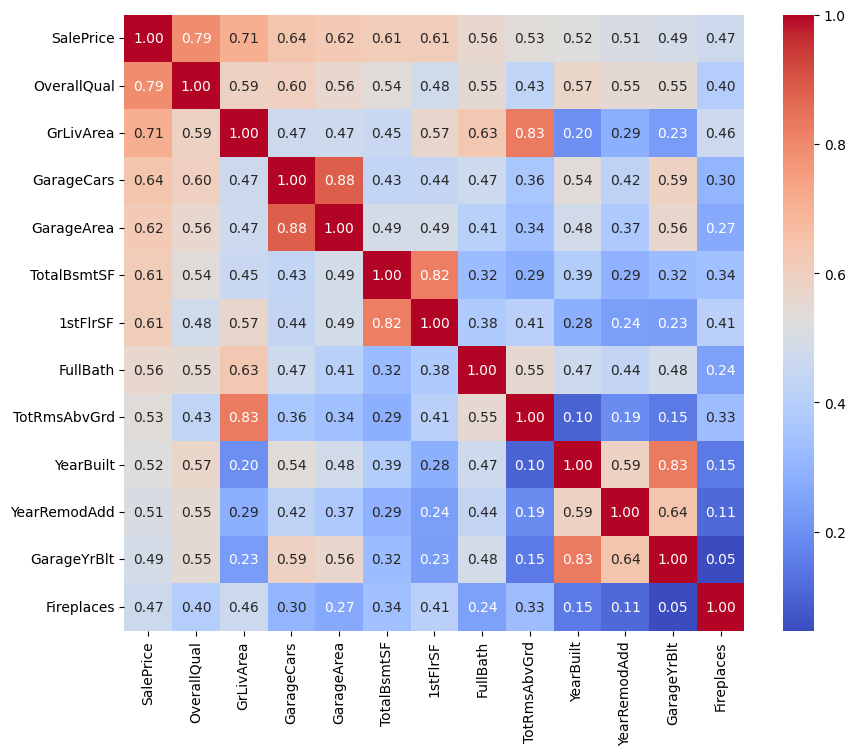

In [1217]:
final_feature = engineer_number_columns(df_output) + list(engineer_object_columns2(df_output).keys())

In [1218]:
len(final_feature)

28

# Feature Engineering


In [1219]:
np.unique(final_feature)

array(['1stFlrSF', 'BsmtExposure', 'BsmtQual', 'CentralAir', 'Electrical',
       'ExterQual', 'Fireplaces', 'Foundation', 'FullBath', 'GarageArea',
       'GarageCars', 'GarageFinish', 'GarageType', 'GarageYrBlt',
       'GrLivArea', 'HeatingQC', 'KitchenQual', 'LotShape',
       'Neighborhood', 'OverallQual', 'PavedDrive', 'RoofStyle',
       'SaleCondition', 'SalePrice', 'TotRmsAbvGrd', 'TotalBsmtSF',
       'YearBuilt', 'YearRemodAdd'], dtype='<U13')

In [1220]:
df_output[final_feature].isna().sum()


SalePrice         0
OverallQual       0
GrLivArea         0
GarageCars        0
GarageArea        0
TotalBsmtSF       0
1stFlrSF          0
FullBath          0
TotRmsAbvGrd      0
YearBuilt         0
YearRemodAdd      0
GarageYrBlt      81
Fireplaces        0
LotShape          0
Neighborhood      0
RoofStyle         0
ExterQual         0
Foundation        0
BsmtQual         37
BsmtExposure     38
HeatingQC         0
CentralAir        0
Electrical        1
KitchenQual       0
GarageType       81
GarageFinish     81
PavedDrive        0
SaleCondition     0
dtype: int64

## 1. '1stFlrSF'


### Nhận xét:

Dữ liệu continuous và phân bố rộng <br>
-> Đề xuất dùng scaler để chuẩn hóa


In [1221]:
from sklearn.preprocessing import StandardScaler

def scale_features(df, feature_list, is_train=True):
    scaler = StandardScaler()
    df_scaled = df.copy()
    if is_train:
        df_scaled[feature_list] = scaler.fit_transform(df_scaled[feature_list])
    else:
        df_scaled[feature_list] = scaler.transform(df_scaled[feature_list])
    return df_scaled

In [1222]:
from sklearn.preprocessing import StandardScaler

def scale_features(df_train, df_test, feature_list):
    feature_list.remove('SalePrice')
    scaler = StandardScaler()
    df_scaled1 = df_train.copy()
    df_scaled2 = df_test.copy()
    df_scaled1[feature_list] = scaler.fit_transform(df_scaled1[feature_list])
    df_scaled2[feature_list] = scaler.transform(df_scaled2[feature_list])
    return df_scaled1, df_scaled2

## 2. 'BsmtExposure'


### Nhận xét:

- Dữ liệu categorical gồm: No, Gd, Mn, Av (No chiếm đa số) <br>
- Giá trị Gd và Mn phân bố khá đều nhau<br>
  -> Đề xuất phân loại thành 3 nhóm và chuyển thành số: 'No': 1, 'Av': 2,'Mn': 2, 'Gd': 3


In [1223]:
cls_BsmtExposure = {'No': 1, 'Av': 2,'Mn': 2, 'Gd': 3}

In [1224]:
cls_feature = {}
cls_feature['BsmtExposure'] = cls_BsmtExposure

In [1225]:
df_output['BsmtExposure'] = df_output['BsmtExposure'].map(cls_BsmtExposure)

In [1226]:
df_output.value_counts('BsmtExposure')

BsmtExposure
1.0    953
2.0    335
3.0    134
Name: count, dtype: int64

## 3. 'BsmtFinType1'


### Nhận xét:

- Dữ liệu categorical gồm: 'Unf': 'GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ' ('GLQ' và 'ALQ' là 2 giá trị chiếm đa số) <br>
- 3 giá trị còn lại phân bố khá đều nhau<br>
  -> Đề xuất phân loại thành 3 nhóm và chuyển thành số: 'Unf': 1, 'GLQ': 2, 'ALQ': 3, 'BLQ': 3, 'Rec': 3, 'LwQ': 3


In [1227]:
cls_BsmtFinType1 = {'Unf': 1, 'GLQ': 2, 'ALQ': 3, 'BLQ': 3, 'Rec': 3, 'LwQ': 3}

In [1228]:
cls_feature['BsmtFinType1'] = cls_BsmtFinType1

In [1229]:
df_output['BsmtFinType1'] = df_output['BsmtFinType1'].map(cls_BsmtFinType1)

Phân bố cột BsmtFinType1 sau khi mapping: Trở thành cột categorical với 3 giá trị


## 4. 'BsmtQual'


## Nhận xét:

- Chiều cao tầng hầm tập trung ở Gd (90-99 inches) và TA (80-89 inches)
- Fa có số lượng thấp nhất
  -> Đề xuất ta sẽ xử lý thành biến phân loại categorical
  'Ex': 1, 'Gd': 2, 'TA': 3, 'Fa': 3, 'Po': 4, 'NA': 0


In [1230]:
cls_BsmtQual = {'Ex': 1, 'Gd': 2, 'TA': 3, 'Fa': 3, 'Po': 4, 'NA': 0}

In [1231]:
cls_feature['BsmtQual'] = cls_BsmtQual

## 5. 'ExterQual'


## Nhận xét:

- Tập trung nhiều ở Gd và TA <br>
  -> Đề xuất thêm mã hóa thành các số


In [1232]:
cls_ExterQual = {'Ex': 1, 'Gd': 2, 'TA': 3, 'Fa': 4, 'Po': 5}

In [1233]:
cls_feature['ExterQual'] = cls_ExterQual

## 6. 'Exterior1st'


## Nhận xét:

- Dữ liệu có tập giá trị khác rộng <br>
  -> Đề xuát: Từ hisplot ta có thể chia thành 4 nhóm khác nhau: Nhóm 1 (VinylSd); Nhóm 2 (MetalSd, Wd Sdng, HdBoard, Plywood), Nhóm 3 (BrkFace, WdShing, CemntBd, AsbShng, Stucco), Nhóm 4 (Others)


In [1234]:
cls_Exterior1st = {
    'VinylSd': 1,
    'MetalSd': 2,
    'Wd Sdng': 2,
    'HdBoard': 2,
    'Plywood': 2,
    'BrkFace': 3,
    'WdShing': 3,
    'CemntBd': 3,
    'AsbShng': 3,
    'Stucco': 3,
    'Others': 4,}

In [1235]:
cls_feature['Exterior1st'] = cls_Exterior1st

## 7. 'Exterior2nd'


## Nhận xét:

- Dữ liệu có tập giá trị khá rộng <br>
  -> Đề xuất chỉnh thành cột phân loại categorical thành 4 nhóm: Nhóm 1 (VinylSd), Nhóm 2 (MetalSd, HdBoard, Plywood, Wd Sgmg,), Nhóm 3 (Wd Shng, BrkFace, CmentBd, Stucco, AsbShng)


In [1236]:
cls_Exterior2nd = {
    'VinylSd': 1,
    'MetalSd': 2,
    'HdBoard': 2,
    'Plywood': 2,
    'Wd Sgmg': 2,
    'Wd Shng': 3,
    'BrkFace': 3,
    'CmentBd': 3,
    'Stucco': 3,
    'AsbShng': 3,
    'Others': 4
    }

In [1237]:
cls_feature['Exterior2nd'] = cls_Exterior2nd

## 8. 'Fireplaces'


<Axes: xlabel='Fireplaces', ylabel='Count'>

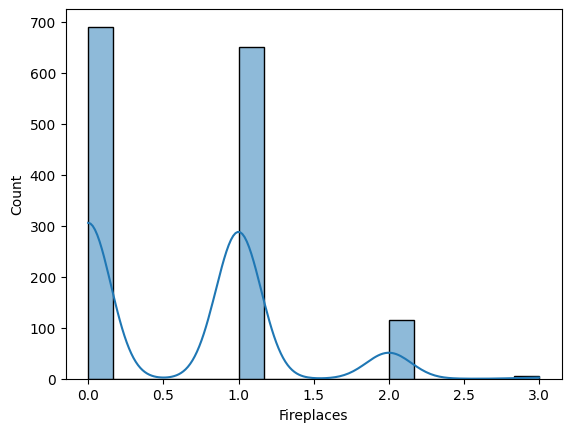

In [1238]:
sns.histplot(data=df_output, x='Fireplaces', kde=True)

## Nhận xét:

- Số lượng lò sưởi phân bố từ 0 - 3
- 0 và 1 và 2 giá trị có nhiều người nhất
  -> Đề xuất dùng scaler để chuẩn hóa giá trị


## 9. 'Foundation'


## Nhận xét:

- Dữ liệu dạng category, phổ biến là 'PConc' và 'CBlock'
  <br>-> Đề xuất chia làm 4 nhóm và mã hóa thành số


In [1239]:
cls_Foundation = {
    'PConc': 1,
    'CBlock':2,
    'BrkTil':3,
    'Others':4
}

In [1240]:
cls_feature['Foundation'] = cls_Foundation

## 10. 'FullBath'


In [1241]:
df_output['FullBath'].isna().sum()

np.int64(0)

In [1242]:
df_output['FullBath'].value_counts()

FullBath
2    768
1    650
3     33
0      9
Name: count, dtype: int64

## Nhận xét:

- Phân bố giá trị từ 0 - 3
- Tạm giữ cột này


## 11. 'GarageArea'


## Nhận xét:

- Dữ liệu phân bố khá đều
  <br> -> Cut thành các nhóm có bins = [-1, 150, 350, 600, 1000, 2000]


In [1243]:
def cut_GarageArea(x):
    if x <= 150:
        return 1
    elif x <= 350:
        return 2
    elif x <= 600:
        return 3
    elif x <= 1000:
        return 4
    else:
        return 5

In [1244]:
cut_feature = {}
cut_feature['GarageArea'] = cut_GarageArea

## 12. 'GarageCars'


## Nhận xét:

- Dữ liệu phân bố từ 0 - 4. Phổ biến nhất là giá trị 2
- Tạm thời giữ nguyên cột này


## 13. 'GarageFinish'


## Nhận xét:

- Dữ liệu dạng categorical với 3 giá trị: RFn, Unf, Fin
  <br> -> Đề xuất mã hóa thành số


In [1245]:
cls_GarageFinish = {
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

In [1246]:
cls_feature['GarageFinish'] = cls_GarageFinish

## 14. 'GarageType'


## Nhận xét:

- Dữ liệu dạng categorical với 6 giá trị
- Có 3 giá trị có tần suất khá thấp
  <br>-> Chia làm 4 khoảng và mã hóa thành số


In [1247]:
cls_GarageType = {
    'Attchd': 1,
    'Detchd': 2,
    'BuiltIn': 3,
    'CarPort': 4,
    'Basment': 4,
    '2Types': 4
}

In [1248]:
cls_feature['GarageType'] = cls_GarageType

## 15. 'GarageYrBlt'


## Nhận xét:

- Số lượng Garage được xây dựng nhiều ở những năm 1990-2000
  <br> -> Đề xuất chia ra thành 3 khoảng


In [1249]:
def cut_GarageYrBlt(x):
    if x >= 1900 and x < 1940:
        return 1
    elif x >= 1940 and x < 1990:
        return 2
    elif x >= 1990 and x <= 2025:
        return 3
    else:
        return 4

In [1250]:
cut_feature['GarageYrBlt'] = cut_GarageYrBlt

## 16. 'GrLivArea'


## Nhận xét:

- Dữ liệu phân bố khá đều
  <br> -> Có thể chia ra thành 4 khoảng: bins = [300,550,2050,8000]


In [1251]:
def cut_GrLivArea(x):
    if x >= 300 and x < 550:
        return 1
    elif x >= 550 and x < 2050:
        return 2
    elif x >= 2050 and x < 8000:
        return 3
    else:
        return 4

In [1252]:
cut_feature['GrLivArea'] = cut_GrLivArea

## 17. 'HeatingQC'


## Nhận xét:

- Dữ liệu dạng Categorical gồm 5 giá trị
  <br>-> Đề xuất mã hóa ra số


In [1253]:
cls_HeatingQC = {
    'Ex': 1,
    'Gd': 2,
    'TA': 3,
    'Fa': 4,
    'Po': 5
}

In [1254]:
cls_feature['HeatingQC'] = cls_HeatingQC

## 18. 'HouseStyle'


## Nhận xét:

- Dữ liệu phân bố không đồng đều, tập trung vào '2Story', '1Story', '1.5Fin'
  <br>-> Đề xuất chia thành 4 nhóm '2Story', '1Story', '1.5Fin' và 'Others'


In [1255]:
cls_HouseStyle = {
    '1Story': 1,
    '2Story': 2,
    '1.5Fin': 3,
    'Others': 4
}

In [1256]:
cls_feature['HouseStyle'] = cls_HouseStyle

## 19. 'KitchenQual'


## Nhận xét:

- Dữ liệu categorical
  -> Đề xuất mã hóa thành số


In [1257]:
cls_KitchenQual = {
    'Ex': 1,
    'Gd': 2,
    'TA': 3,
    'Fa': 4,
    'Po': 5
}

In [1258]:
cls_feature['KitchenQual'] = cls_KitchenQual

## 20. 'LandSlope'


## Nhận xét:

- Dữ liệu lệch hẳn về Gtl
- Mất cân bằng
  -> Đề xuất drop


In [1259]:
# drop_cols = ['LandSlope']
if 'LandSlope' in final_feature:
    final_feature.remove('LandSlope')

## 21. 'LotConfig'


## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Inside' và 'Corner'
  <br>-> Đề xuất tạo 3 nhóm vào mã hóa thành số


In [1260]:
cls_LotConfig = {
    'Inside': 1,
    'Corner': 2,
    'others': 3
}

In [1261]:
cls_feature['LotConfig'] = cls_LotConfig

## 22. 'LotShape'


## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Reg' và 'IR1'
  <br>-> Đề xuất tạo 3 nhóm và mã hóa thành số


In [1262]:
cls_LotShape = {
    'Reg': 1,
    'IR3': 2,
    'Others': 3
}

In [1263]:
cls_feature['LotShape'] = cls_LotShape

## 23. 'MSZoning'


## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'RL' và 'RM'
  <br>-> Đề xuất tạo 3 nhóm vào mã hóa thành số


In [1264]:
cls_MSZoning = {
    'RL': 1,
    'RM': 2,
    'Others': 3
}

In [1265]:
cls_feature['MSZoning'] = cls_MSZoning

## 24. 'Neighborhood'


## Nhận xét:

- Dữ liệu có tập giá trị khá rộng
- Có thể sử dụng TargetEncoder để mã hóa


In [1266]:
!pip install category_encoders


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1267]:
from category_encoders import TargetEncoder
# def target_encode_feature(df, feature_name, target_name='SalePrice', is_train=True):
#     encoder = TargetEncoder()
#     if is_train:
#         df[feature_name] = encoder.fit_transform(df[feature_name], df[target_name])
#     else:
#         df[feature_name] = encoder.transform(df[feature_name])
#     return df

In [1268]:
def target_encode_feature_(df_train, df_test, feature_name, target_name='SalePrice'):
    encoder = TargetEncoder()
    df_train[feature_name] = encoder.fit_transform(df_train[feature_name], df_train[target_name])
    df_test[feature_name] = encoder.transform(df_test[feature_name])
    return df_train, df_test

## 25. 'OverallQual'


## Nhận xét:

- Dữ liệu phân bố tập trung từ 5-8
  <br> -> Có thể tách ra thành 3 khoảng


In [1269]:
def cut_OverallQual(x):
    if x <= 4:
        return 1
    elif x >= 5 and x <= 8:
        return 2
    else:
        return 3

In [1270]:
cut_feature['OverallQual'] = cut_OverallQual

## 26. 'RoofStyle'


## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Gable' và 'Hip'
  <br>-> Đề xuất tạo 3 nhóm vào mã hóa thành số


In [1271]:
cls_RoofStyle = {
    'Gable':1,
    'Hip': 2,
    'Others':3
}

In [1272]:
cls_feature['RoofStyle'] = cls_RoofStyle

## 27. 'SaleCondition'


## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Normal', 'Abnorml' và 'Partial'
  <br>-> Đề xuất tạo 4 nhóm vào mã hóa thành số


In [1273]:
cls_SaleCondition = {
    'Normal': 1,
    'Partial': 2,
    'Abnorml':3,
    'Others': 4

}

In [1274]:
cls_feature['SaleCondition'] = cls_SaleCondition

## 28. 'TotRmsAbvGrd'


## Nhận xét:

- Dữ liệu phân bố tập trung từ 5-7
  <br> -> Có thể tách ra thành 3 khoảng


In [1275]:
def cut_TotRmsAbvGrd(x):
    if x <= 4:
        return 1
    elif x >= 5 and x <= 7:
        return 2
    else:
        return 3

In [1276]:
cut_feature['TotRmsAbvGrd'] = cut_TotRmsAbvGrd

## 29. 'TotalBsmtSF'


## Nhận xét:

- Dữ liệu phân bố tập trung từ 600-2000
  <br> -> Đề xuất dùng scale


## 30. 'YearBuilt' và 'YrSold'


### Chúng ta sẽ xây dựng thuộc tính HouseAge để tính tuổi của nhà


In [1277]:
def engineer_HouseAge(df):
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    final_feature.insert(0, 'HouseAge')
    return df

## 31. 'YearRemodAdd'


### Chúng ta sẽ xây dựng thuộc tính IsRemodeled để xem căn nhà đã sửa qua chưa


In [1278]:
def engineer_IsRemodeled(df):
    df['IsRemodeled'] = np.where(df['YearRemodAdd'] != df['YearBuilt'], 1, 0)
    final_feature.insert(0, 'IsRemodeled')
    return df

In [1279]:
for col in cls_feature:
    print(f'Encoding column: {col}')

Encoding column: BsmtExposure
Encoding column: BsmtFinType1
Encoding column: BsmtQual
Encoding column: ExterQual
Encoding column: Exterior1st
Encoding column: Exterior2nd
Encoding column: Foundation
Encoding column: GarageFinish
Encoding column: GarageType
Encoding column: HeatingQC
Encoding column: HouseStyle
Encoding column: KitchenQual
Encoding column: LotConfig
Encoding column: LotShape
Encoding column: MSZoning
Encoding column: RoofStyle
Encoding column: SaleCondition


## 32. 'CentralAir'


In [1280]:
cls_CentralAir = {
    'Y': 1,
    'N': 0
}

In [1281]:
cls_feature['CentralAir'] = cls_CentralAir

In [1282]:
df_output['CentralAir'] = df_output['CentralAir'].map(cls_CentralAir)

## 33. 'Electrical'


In [1283]:
cls_Electrical = {
    'SBrkr': 1,
    'FuseA': 2,
    'Others': 3
}

In [1284]:
cls_feature['Electrical'] = cls_Electrical

In [1285]:
df_output['Electrical'] = df_output['Electrical'].map(lambda x: cls_Electrical[x] if x in cls_Electrical else cls_Electrical['Others'])

## 34. 'PavedDrive'


In [1286]:
cls_PavedDrive = {
    'Y': 1,
    'N': 2,
    'P': 3
}   

In [1287]:
cls_feature['PavedDrive'] = cls_PavedDrive

In [1288]:
df_output['PavedDrive'] = df_output['PavedDrive'].map(cls_PavedDrive)

In [1289]:
def preprocessing_feature_01(df_data, is_train = True, is_debug = True, **kwargs):
    df_output = pd.DataFrame()
    df_output = df_data.copy()

    # Chuẩn bị các cột map và cut
    for col in cls_feature.keys():
        if 'Others' in cls_feature[col].keys():
            df_output[col] = df_output[col].map(lambda x: cls_feature[col][x] if x in cls_feature[col] else cls_feature[col]['Others']) 
        else:
            df_output[col] = df_output[col].apply(lambda x: cls_feature[col].get(x, 0) if pd.notna(x) else cls_feature[col].get(df_output[col].mode()[0], 0))
        
    for col in cut_feature.keys():
        df_output[col] = df_output[col].apply(cut_feature[col])

    # Xây dựng thêm các thuộc tính mới
    df_output = engineer_HouseAge(df_output)
    df_output = engineer_IsRemodeled(df_output)


    # Drop các cột không sử dụng
    for x in df_train.columns:
        if x not in final_feature:
            df_output = df_output.drop(columns=[x], axis=1)

    if is_train:
        df_output["Output"] = df_data["SalePrice"]
        df_output = df_output.drop(columns=['SalePrice'], axis=1)

    # Check missing sau tiền xử lý
    # Kiểm tra missing value cho từng cột
    for col in df_output.columns:
        missing_count = df_output[col].isna().sum()
        if missing_count > 0:
            print(f"Column {col}: {missing_count} missing values")
            
            # Xử lý missing value tùy theo loại dữ liệu
            if df_output[col].dtype == 'object':
                # Với cột categorical: điền bằng mode
                mode_value = df_train[col].mode()[0]
                df_output[col] = df_output[col].fillna(mode_value)
            else:
                # Với cột numeric: điền bằng median 
                median_value = df_train[col].median()
                df_output[col] = df_output[col].fillna(median_value)

    if is_debug:
        print("head(5)")
        display.display(df_output.head(5))
        print("isna")
        display.display(df_output.isna().sum())
        print("Columns:", df_output.columns.tolist())
        print("Shape:", df_output.shape)

    return df_output, None
    pass

# df_train = pd.read_csv(f'{data_dir}/train.csv')
# preprocessing_feature_01(df_train)

# Main


In [1290]:
def main_feat01(**kwargs):
    # load data
    df_train = pd.read_csv(f'{data_dir}/train.csv')
    df_test = pd.read_csv(f'{data_dir}/test.csv')
    # preprocessing
    df_output_train, _ = preprocessing_feature_01(df_train, is_train=True, is_debug=False)
    df_output_test, _ = preprocessing_feature_01(df_test, is_train=False, is_debug=False)
    # Encoder Neighborhood with Target Encoder
    
    df_output_train, df_output_test = target_encode_feature_(df_output_train, df_output_test, feature_name='Neighborhood', target_name='Output')
    df_output_train, df_output_test = scale_features(df_output_train, df_output_test, feature_list=final_feature)
    # saving
    os.makedirs(save_dir, exist_ok=True)
    
    # Lưu trực tiếp DataFrame objects (cần allow_pickle=True khi load)
    np.savez(f'{save_dir}/data.npz', 
             train_data=df_output_train.values,
             test_data=df_output_test.values,
             train_columns=df_output_train.columns.values,  # Lưu tên cột train
             test_columns=df_output_test.columns.values,
             allow_pickle=True)
    
    print("Đã lưu DataFrame với đầy đủ thông tin cột")

    kwargs.get('global_cfg', {}).update(**locals())

if params_cfg["action"] == "train_feat01":
    print("Runing ... [train_feat01]")
    main_feat01(global_cfg = globals())

Runing ... [train_feat01]
Column TotalBsmtSF: 1 missing values
Column GarageCars: 1 missing values
Đã lưu DataFrame với đầy đủ thông tin cột


# End
